In [17]:
import pandas as pd 
import numpy as np 
import statsmodels.api as sm 
import matplotlib.pyplot as plt

In [18]:
DF = pd.read_excel('SP500Raw.xlsx')
DF['date'] = pd.to_datetime(DF['date'])
DF = DF.set_index(keys=['date','permno'])
DF

,,price,shrout,prc,mcap
date,permno,,,,
2010-01-29,10104,23.06000,5011220,-0.057888,1.155587e+08
2010-02-26,10104,24.65000,5015000,0.068951,1.236198e+08
2010-03-31,10104,25.71000,5019091,0.043002,1.290408e+08
2010-04-30,10104,25.86750,5029523,0.008071,1.301012e+08
2010-05-28,10104,22.57000,5026000,-0.127477,1.134368e+08
...,...,...,...,...,...
2024-08-30,93436,214.11000,3194640,-0.077391,6.840044e+08
2024-09-30,93436,261.63000,3207000,0.221942,8.390474e+08
2024-10-31,93436,249.85001,3210060,-0.045025,8.020335e+08


## Basic checks of data consistency and visualization 

In [19]:
DF.describe()

,price,shrout,prc,mcap
count,90517.000000,9.052500e+04,90471.000000,9.051700e+04
mean,114.310440,6.208745e+05,0.011204,4.828252e+07
std,230.655848,1.191071e+06,0.085348,1.264082e+08
min,1.480000,3.064000e+03,-0.886269,6.203644e+05
25%,38.660000,1.584690e+05,-0.036248,1.059996e+07
50%,66.720000,3.002210e+05,0.011526,1.955465e+07
75%,118.360000,5.852470e+05,0.057079,4.227438e+07
max,9811.799800,2.920640e+07,2.135168,3.785304e+09


array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'shrout'}>],
       [<Axes: title={'center': 'prc'}>,
        <Axes: title={'center': 'mcap'}>]], dtype=object)

<Figure size 640x480 with 0 Axes>

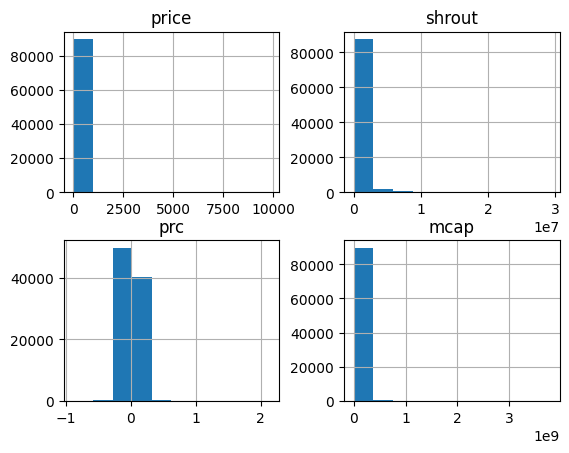

In [20]:
plt.tight_layout()
DF.hist()

In [21]:
DF.isna().sum()

price      8
shrout     0
prc       54
mcap       8
dtype: int64

# Question 2 mismatch between prc and percent change and Price_Ret(T1)

In [10]:
DF['price_ret(t1)'] = DF['price']/DF['price'].shift(1)-1
DF

,,price,shrout,prc,mcap,price_ret(t1)
date,permno,,,,,
2010-01-29,10104,23.06000,5011220,-0.057888,1.155587e+08,NaN
2010-02-26,10104,24.65000,5015000,0.068951,1.236198e+08,0.068951
2010-03-31,10104,25.71000,5019091,0.043002,1.290408e+08,0.043002
2010-04-30,10104,25.86750,5029523,0.008071,1.301012e+08,0.006126
2010-05-28,10104,22.57000,5026000,-0.127477,1.134368e+08,-0.127477
...,...,...,...,...,...,...
2024-08-30,93436,214.11000,3194640,-0.077391,6.840044e+08,-0.077390
2024-09-30,93436,261.63000,3207000,0.221942,8.390474e+08,0.221942
2024-10-31,93436,249.85001,3210060,-0.045025,8.020335e+08,-0.045025


In [ ]:
#checking for 